# How Does Political Knowledge impact levels of Affective Polarization
- H1: low levels of political knowledge lead to increased levels of affective polarization


In [ ]:
# Load relevant packages
import numpy as np
import pandas as pd
# import seaborn as sns
# import statsmodels.formula.api as sm

# from statsmodels.iolib.summary2 import summary_col
# from matplotlib import pyplot as plt

In [43]:
# Load the data
data_url = "https://raw.githubusercontent.com/datamisc/ts-2020/main/data.csv"
anes_data = pd.read_csv(data_url, compression='gzip')

/tmp/ipykernel_914748/424094380.py:3: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_data = pd.read_csv(data_url, compression='gzip')


In [44]:
# Creating a dictionnary of interesting variables
vars = {
    "V201033": "vote_intention",
    "V201507x": "age",
    "V201600": "sex",
    "V201511x": "education",
    "V201617x": "income",
    "V201228": "party_id",
    "V201231x": "party_id_str",
    "V201232": "party_id_imp",
    "V201200": "ideology",
    "V201156": "feeling_democrat",
    "V201157": "feeling_republican",
    "V201641": "political_knowledge_intro",
    "V201642": "political_knowledge_catch1",
    "V201643": "political_knowledge_catch_feedback",
    "V201644": "political_knowledge_senate_term",
    "V201645": "political_knowledge_least_spending",
    "V201646": "political_knowledge_house_majority",
    "V201647": "political_knowledge_senate_majority",
    "V202406": "political_interest",
    "V202407": "follow_politics_media",
    "V202408": "understand_issues"
}


In [45]:
# Select & Rename variables to make them more descriptive
df = anes_data[vars.keys()]
df = df.rename(columns=vars)

# Step 2: Clean & Create Relevant Variables
We will create a political knowledge scale by summing the correct answers to the political knowledge questions.


In [46]:
# Quick Data Cleaning | WARNING We could be dropping relevant observations!

# age
mask = df['age'] >= 18
df = df[mask]

# sex
mask = df['sex'].between(1,2)
df = df[mask]
df['female'] = df['sex'].map({1: 0, 2: 1})
# Or with lambda
# df['female'] = df['sex'].apply(lambda x: 1 if x == 2 else 0)

# education
mask = df['education'] > 0
df = df[mask]

# ideology
mask = df['ideology'].between(1,7)
df = df[mask]

mask = df['party_id'].between(1,3)
df = df[mask]

# vote_intention
mask = df['vote_intention'].between(1,2)  # We are keeping intentions for major parties
df = df[mask]

# You could also skip the mask step
# political_interest
df = df[df['political_interest'] > 0]

# follow_politics_media
df = df[df['follow_politics_media'] > 0]

# understand_issues
df = df[df['understand_issues'] > 0]


# Step 3: Build Quantities of Interests


In [48]:
# Build an Affective Polarization Variable (DV)
# We calculate affective polarization based on feeling thermometer scores.
mask = (df['feeling_democrat'] >= 0) & (df['feeling_republican'] >= 0 )
df = df[mask]

df['affective_polarization'] = np.abs(df['feeling_democrat'] - df['feeling_republican'])

/tmp/ipykernel_914748/1232994512.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['affective_polarization'] = np.abs(df['feeling_democrat'] - df['feeling_republican'])


In [49]:
# Creating a Poliitcal Knowledge Scale Variable (IV)

# First we identify the variable we need
political_knowledge_vars = [
    "political_knowledge_senate_term",
    "political_knowledge_least_spending",
    "political_knowledge_house_majority",
    "political_knowledge_senate_majority"
]

In [50]:
# Define a function to clean and recode political knowledge responses
def clean_knowledge_variable(series, correct_values):
    # Replace invalid codes with NaN
    series_cleaned = series.replace([-9, -5, -4, -1], np.nan)
    # Recode correct answers as 1, others as 0
    series_cleaned = series_cleaned.apply(lambda x: 1 if x in correct_values else 0)
    return series_cleaned

In [51]:
# Apply the created function
df['political_knowledge_senate_term'] = clean_knowledge_variable(df['political_knowledge_senate_term'], [6])
df['political_knowledge_least_spending'] = clean_knowledge_variable(df['political_knowledge_least_spending'], [1])
df['political_knowledge_house_majority'] = clean_knowledge_variable(df['political_knowledge_house_majority'], [1])
df['political_knowledge_senate_majority'] = clean_knowledge_variable(df['political_knowledge_senate_majority'], [2])

/tmp/ipykernel_914748/994038314.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['political_knowledge_senate_term'] = clean_knowledge_variable(df['political_knowledge_senate_term'], [6])
/tmp/ipykernel_914748/994038314.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['political_knowledge_least_spending'] = clean_knowledge_variable(df['political_knowledge_least_spending'], [1])
/tmp/ipykernel_914748/994038314.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [52]:
# Finally sum the values over the Political Knowledge variables
print(df[political_knowledge_vars].head())
df['political_knowledge_scale'] = df[political_knowledge_vars].sum(axis=1)

   political_knowledge_senate_term  political_knowledge_least_spending  \
0                                1                                   0   
2                                1                                   1   
3                                0                                   1   
4                                1                                   1   
5                                0                                   0   

   political_knowledge_house_majority  political_knowledge_senate_majority  
0                                   1                                    1  
2                                   1                                    1  
3                                   0                                    0  
4                                   1                                    1  
5                                   1                                    1  


/tmp/ipykernel_914748/2101213534.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['political_knowledge_scale'] = df[political_knowledge_vars].sum(axis=1)


<Axes: title={'center': 'Density Plot'}, ylabel='Density'>

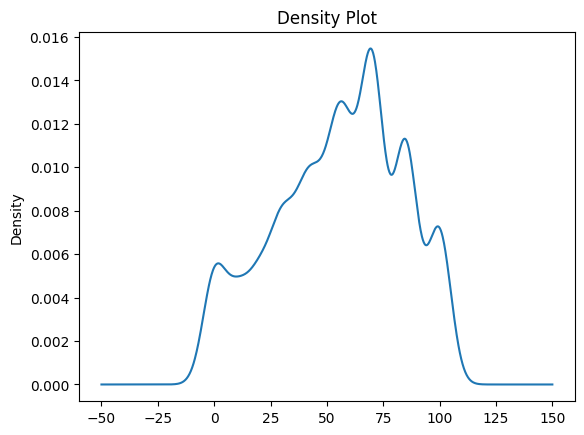

In [ ]:
## Take a look at our DV
df['affective_polarization'].plot(kind='kde', title='Density Plot')

<Axes: xlabel='affective_polarization', ylabel='Density'>

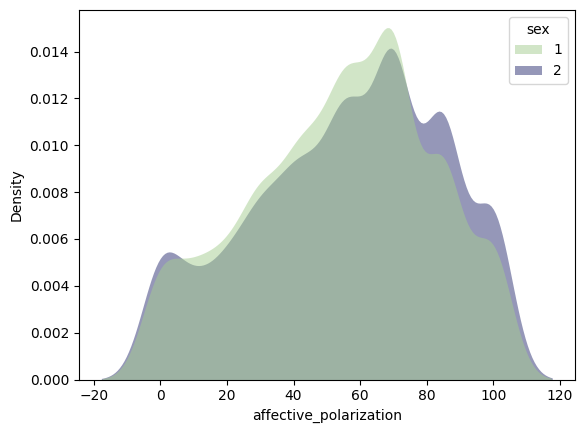

In [54]:
## Or using Seaborn!
sns.kdeplot(
   data=df, x="affective_polarization", hue="sex",
   fill=True, common_norm=False, palette="crest",
   alpha=.5, linewidth=0,
)

<Axes: title={'center': 'Distribution of Political Knowledge Scale'}, xlabel='political_knowledge_scale'>

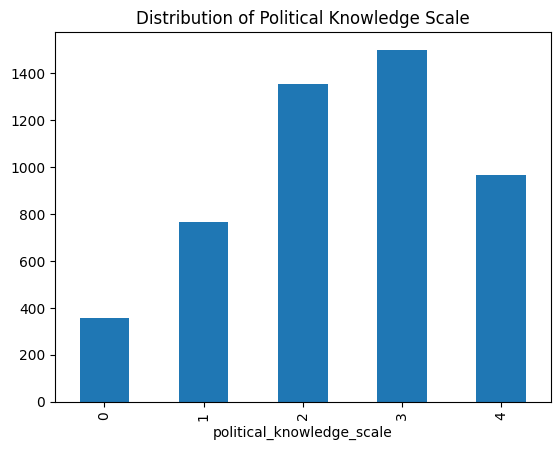

In [55]:
# Take a look at the IV
df['political_knowledge_scale'].value_counts().sort_index().plot(
    kind='bar',
    title="Distribution of Political Knowledge Scale"
)


### Step 4: Modeling – Build a Regression Model

We will use the cleaned data in `df` to build a regression model, including control variables like age, sex, income, and ideology. 

We can use the **`statsmodels` formula API** to write models in a simple, readable formula style (e.g., `vote_biden ~ age + sex + income + ideology`). This makes it easy to specify and fit the model while controlling for multiple vairables.

For more examples, see the [Statsmodels Formulas Documentation](https://www.statsmodels.org/stable/example_formulas.html).

**TIP:** Make sure you have loaded the correct libraries.

In [67]:
# First we define the model formula
# It takes the following form DV ~ IV + CV

formula1 = "affective_polarization ~ political_knowledge_scale + age + sex + ideology + party_id"

In [68]:
# Fit the regression model
model1 = sm.ols(formula=formula1, data=df).fit()

Print the summary of the model below and look at sex and party_id variables. 
- How have those been coded? Should we change the model?

In [75]:
# Print the summary of the regression model
print(model1.summary())

                              OLS Regression Results                              
Dep. Variable:     affective_polarization   R-squared:                       0.151
Model:                                OLS   Adj. R-squared:                  0.150
Method:                     Least Squares   F-statistic:                     175.9
Date:                    Mon, 02 Mar 2026   Prob (F-statistic):          8.85e-173
Time:                            13:53:04   Log-Likelihood:                -23097.
No. Observations:                    4944   AIC:                         4.621e+04
Df Residuals:                        4938   BIC:                         4.625e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

Since `party_id` and `sex` are **categorical variables** , we need to wrap them in `C()` in the formula: `C(party_id)` and `C(sex)` or use the `female` variable, that we created earlier, directly in the formula. This tells `statsmodels` to treat the variales as categories and it will automatically create dummy variables, so the model can compare one group to a reference group. 

Using `C()` ensures that categorical variables are interpreted correctly in the regression instead of being treated as numeric values.


In [70]:
# Fixing the formula
formula2 = "affective_polarization ~ political_knowledge_scale + age + female + ideology + C(party_id)"

In [76]:
model2 = sm.ols(formula=formula2, data=df).fit()
print(model2.summary())

                              OLS Regression Results                              
Dep. Variable:     affective_polarization   R-squared:                       0.171
Model:                                OLS   Adj. R-squared:                  0.170
Method:                     Least Squares   F-statistic:                     169.8
Date:                    Mon, 02 Mar 2026   Prob (F-statistic):          7.58e-197
Time:                            13:54:07   Log-Likelihood:                -23039.
No. Observations:                    4944   AIC:                         4.609e+04
Df Residuals:                        4937   BIC:                         4.614e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [77]:
# If you want to compare model syou can also use the `summary_col` function from statsmodels
print(summary_col([model1, model2]))



                          affective_polarization I affective_polarization II
----------------------------------------------------------------------------
Intercept                 44.2740                  37.6556                  
                          (2.1927)                 (1.6669)                 
political_knowledge_scale 1.6438                   1.7959                   
                          (0.3325)                 (0.3290)                 
age                       0.2234                   0.2306                   
                          (0.0229)                 (0.0226)                 
sex                       2.0787                                            
                          (0.7645)                                          
ideology                  3.7508                   1.4775                   
                          (0.2352)                 (0.3128)                 
party_id                  -12.1804                                         

In [ ]:
# Exporting the tables
TODO

SyntaxError: invalid syntax (1762884869.py, line 1)

# Step 5: Visualize Results
Create a visualization to summarize the results of the regression model.


In [79]:
# Create a DataFrame with coefficients and confidence intervals
coef_df = pd.DataFrame({
    'coef': model1.params,
    'lower_ci': model1.conf_int()[0],
    'upper_ci': model1.conf_int()[1],
    'pval': model1.pvalues
}).drop('Intercept')


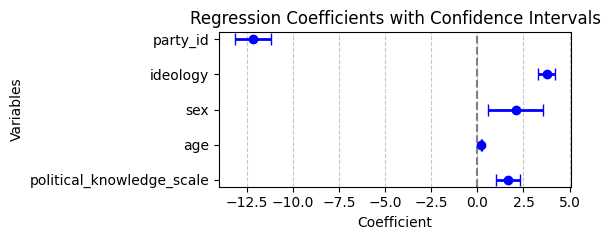

In [90]:
# Make the figure
plt.figure(figsize=(6,2.5))
# Plot each coefficient with its confidence interval
plt.errorbar(coef_df['coef'], coef_df.index, xerr=(coef_df['coef'] - coef_df['lower_ci'], coef_df['upper_ci'] - coef_df['coef']), fmt='o', color='b', elinewidth=2, capsize=4)
plt.axvline(x=0, color='grey', linestyle='--')  # Add a vertical line at zero for reference
plt.title('Regression Coefficients with Confidence Intervals')
plt.xlabel('Coefficient')
plt.ylabel('Variables')
plt.yticks(ticks=range(len(coef_df)), labels=coef_df.index)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
